# Модуль 4. Градиентный бустинг для регрессии: интуиция через остатки

**Интерактивная версия:** `lessons/lesson_4/web/index.html`

Алгоритм в 10 строк, сверка с scikit-learn и анимация шагов в виде «малых множителей».

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style, plot_boosting_step, plot_stages, plot_learning_curves

use_course_style()

## 1. Алгоритм в 10 строк

In [2]:
X, y = datasets.regression_1d(kind="wave", n=100, noise=0.35, seed=42)
nu, M = 0.1, 150
F = np.full_like(y, y.mean())
for _ in range(M):
    r = y - F
    h = DecisionTreeRegressor(max_depth=2).fit(X, r)
    F = F + nu * h.predict(X)
sk = GradientBoostingRegressor(n_estimators=M, learning_rate=nu, max_depth=2).fit(X, y)
print("расхождение с sklearn:", np.abs(F - sk.predict(X)).max())

расхождение с sklearn: 0.0


## 2. Первые шаги крупным планом

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


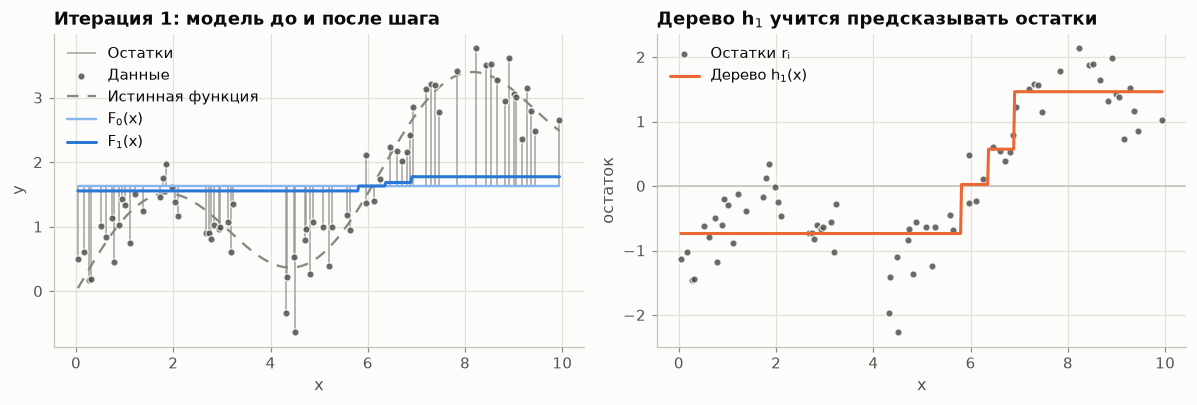

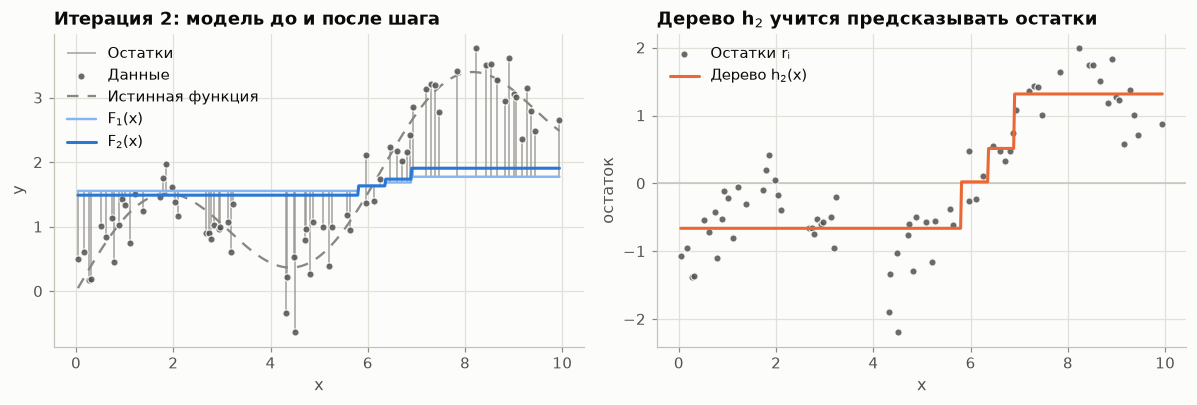

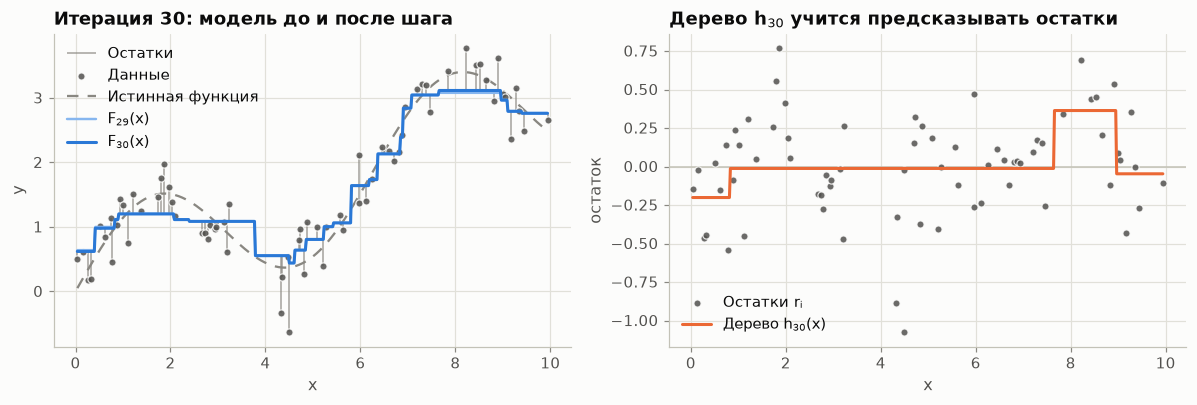

In [3]:
X_tr, X_val, y_tr, y_val = datasets.train_test_split(X, y, test_size=0.3, seed=0)
model = GBRegressor(n_estimators=150, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr, eval_set=(X_val, y_val))
for m in (1, 2, 30):
    plot_boosting_step(model, X_tr, y_tr, m, truth_kind="wave")
    plt.tight_layout()
    plt.show()

## 3. Модель после разного числа деревьев и кривые потерь

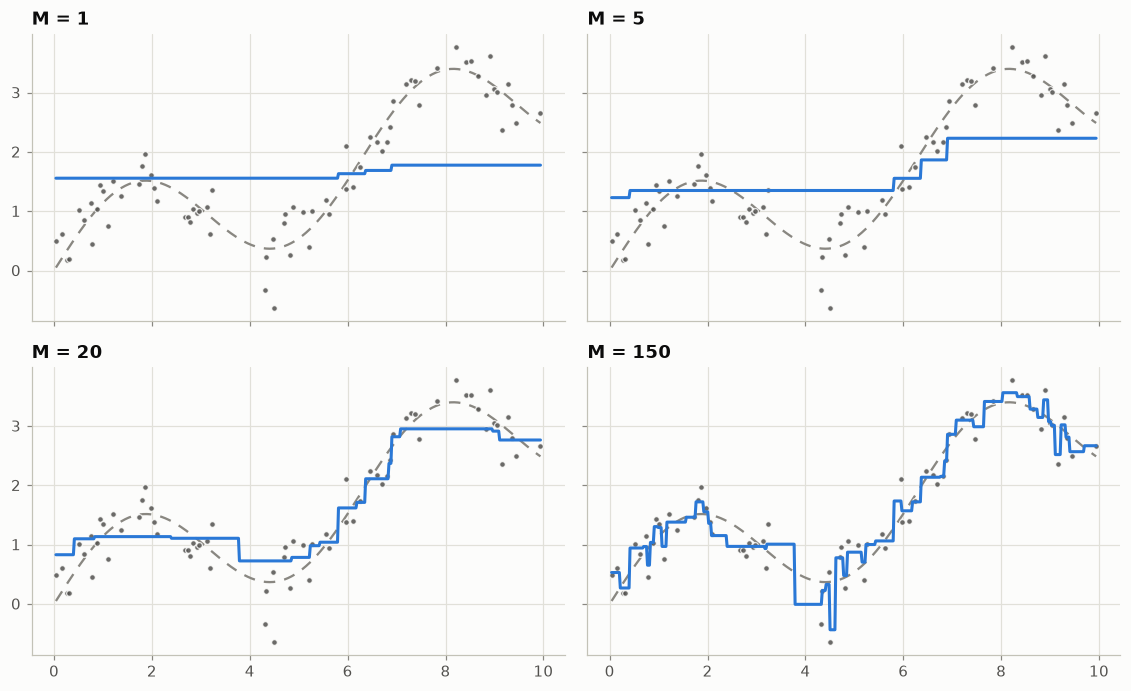

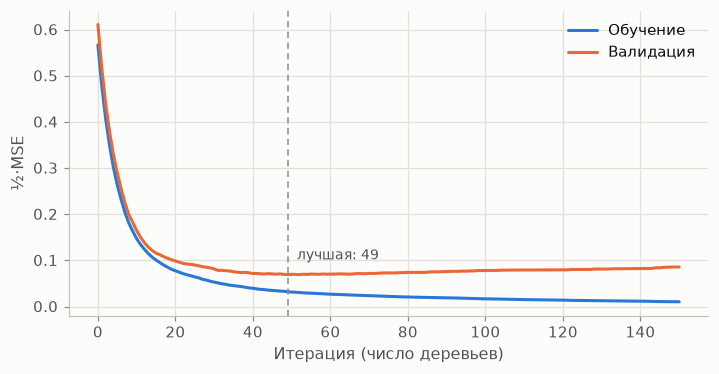

In [4]:
plot_stages(model, X_tr, y_tr, stages=(1, 5, 20, 150), truth_kind="wave")
plt.show()
fig, ax = plt.subplots(figsize=(7.5, 3.6))
plot_learning_curves(ax, model.history_, best_iteration=model.best_iteration_, ylabel="½·MSE")
plt.show()

## Упражнения

1. Сколько деревьев нужно, чтобы потери на обучении упали вдвое относительно $F_0$?
2. Повторите п. 3 с `learning_rate=1.0`. Где теперь лучшая итерация по валидации?

Решения: `python lessons/lesson_4/exercises/solutions.py`.